⏳ Đang tải, gộp dữ liệu và tính toán Vận tốc...
✅ Tổng số lượt thu thập (Runs): 55 | Tổng số dòng: 4600
✅ Số lượt dùng cho Train: 44 | Dùng cho Test độc lập: 11
✅ Kích thước X_train: (2871, 25, 3) | X_test: (432, 25, 3)

🚀 BẮT ĐẦU HUẤN LUYỆN...
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5409 - loss: 0.9225 - val_accuracy: 0.6574 - val_loss: 0.7847 - learning_rate: 0.0010
Epoch 2/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6782 - loss: 0.7550 - val_accuracy: 0.6366 - val_loss: 0.7752 - learning_rate: 0.0010
Epoch 3/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7172 - loss: 0.6707 - val_accuracy: 0.6875 - val_loss: 0.7075 - learning_rate: 0.0010
Epoch 4/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7416 - loss: 0.6067 - val_accuracy: 0.6667 - val_loss: 0.7003 - learning_rate: 0.0010
Epoch 5/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7666 - loss: 0.5573 - val_accuracy: 0.6921 - val_loss: 0.6749 - learning_rate: 0.0010
Epoch 6/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7698 - loss: 0.5094 - val_accuracy: 0.6736 - val_loss: 0.6839 - learning_rate: 0.0010
Epoch 7/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8053 - loss: 0.4615 - val_accuracy: 0.710

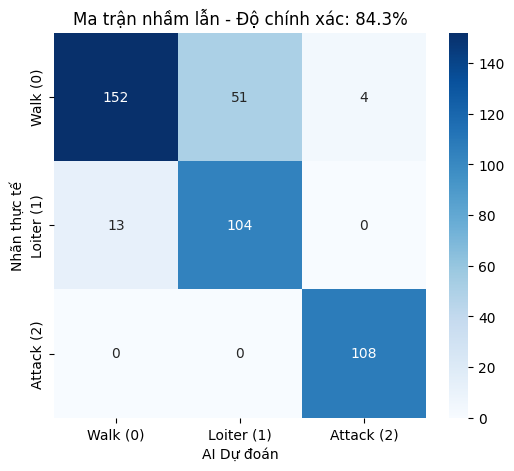


📋 BÁO CÁO PHÂN LOẠI:
              precision    recall  f1-score   support

    Walk (0)       0.92      0.73      0.82       207
  Loiter (1)       0.67      0.89      0.76       117
  Attack (2)       0.96      1.00      0.98       108

    accuracy                           0.84       432
   macro avg       0.85      0.87      0.85       432
weighted avg       0.86      0.84      0.84       432

⏳ Đang biên dịch sang TFLite C Array...
Saved artifact at '/tmp/tmp2de71wex'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 25, 3), dtype=tf.float32, name='keras_tensor_9')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  137603644707216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137604603436048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137604603437008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137604603445072: TensorSpec(shape=(), dtype=tf.resource, name=Non

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ==========================================
# 1. CẤU HÌNH THÔNG SỐ (HYPERPARAMETERS)
# ==========================================
FILES = ['uwb_lstm_data_label0.csv', 'uwb_lstm_data_label1.csv', 'uwb_lstm_data_label2.csv']
TIME_STEPS = 25      # Tăng lên 25 frames (2.5 giây) để AI nhìn trọn vẹn hành động "đi vào rồi lùi ra"
STEP_SIZE = 1
BATCH_SIZE = 32
EPOCHS = 100         # Tăng từ 50 lên 100 vòng vì dữ liệu giờ đã nhiều và phức tạp hơn
TEST_SPLIT = 0.2
# ==========================================
# 2. ĐỌC, GỘP DỮ LIỆU & TẠO FEATURE "VELOCITY"
# ==========================================
print("⏳ Đang tải, gộp dữ liệu và tính toán Vận tốc...")
df_list = []
global_run_id = 0

for file in FILES:
    if os.path.exists(file):
        temp_df = pd.read_csv(file)
        # Sắp xếp chuẩn theo run_id và thời gian
        temp_df = temp_df.sort_values(by=['run_id', 'timestamp_ms'])

        # TÍNH VẬN TỐC (Sự thay đổi khoảng cách)
        temp_df['velocity'] = temp_df.groupby('run_id')['filtered_m'].diff().fillna(0)

        # Cập nhật run_id để không trùng lặp giữa các file
        unique_runs = temp_df['run_id'].unique()
        run_mapping = {old_run: global_run_id + i for i, old_run in enumerate(unique_runs)}
        temp_df['run_id'] = temp_df['run_id'].map(run_mapping)
        global_run_id += len(unique_runs)

        df_list.append(temp_df)
    else:
        print(f"⚠️ Cảnh báo: Không tìm thấy {file} trên Colab. Hãy chắc chắn em đã Upload!")

if not df_list:
    raise ValueError("❌ Không có file dữ liệu nào. Dừng chương trình.")

df = pd.concat(df_list, ignore_index=True)
features = ['filtered_m', 'residual_m', 'velocity'] # 3 Đặc trưng sức mạnh
print(f"✅ Tổng số lượt thu thập (Runs): {df['run_id'].nunique()} | Tổng số dòng: {len(df)}")

# ==========================================
# 3. CHIA TẬP TRAIN/TEST THEO RUN (CHỐNG RÒ RỈ DỮ LIỆU)
# ==========================================
all_runs = df['run_id'].unique()
np.random.seed(42)
np.random.shuffle(all_runs)

split_idx = int(len(all_runs) * (1 - TEST_SPLIT))
train_runs = all_runs[:split_idx]
test_runs = all_runs[split_idx:]

train_df = df[df['run_id'].isin(train_runs)].copy()
test_df = df[df['run_id'].isin(test_runs)].copy()
print(f"✅ Số lượt dùng cho Train: {len(train_runs)} | Dùng cho Test độc lập: {len(test_runs)}")

# ==========================================
# 4. CHUẨN HÓA DỮ LIỆU (FIT TRÊN TRAIN, BIẾN ĐỔI TRÊN CẢ 2)
# ==========================================
# scaler = StandardScaler()
# train_df.loc[:, features] = scaler.fit_transform(train_df[features])
# test_df.loc[:, features] = scaler.transform(test_df[features])


# Cập nhật Phần 4
scaler = RobustScaler()
train_df.loc[:, features] = scaler.fit_transform(train_df[features])
test_df.loc[:, features] = scaler.transform(test_df[features])

# ==========================================
# 5. CẮT CỬA SỔ TRƯỢT (SLIDING WINDOW)
# ==========================================
def create_sequences(data, time_steps, step_size):
    X, y = [], []
    for run_id, group in data.groupby('run_id'):
        if len(group) < time_steps:
            continue
        feature_values = group[features].values
        labels = group['label'].values

        for i in range(0, len(group) - time_steps + 1, step_size):
            X.append(feature_values[i : (i + time_steps)])
            y.append(np.bincount(labels[i : (i + time_steps)]).argmax())

    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_df, TIME_STEPS, STEP_SIZE)
X_test, y_test = create_sequences(test_df, TIME_STEPS, STEP_SIZE)
print(f"✅ Kích thước X_train: {X_train.shape} | X_test: {X_test.shape}")

# ==========================================
# 6. THAY THẾ BẰNG KIẾN TRÚC CONV-1D (SIÊU NHẸ CHO ESP32)
# ==========================================
model = Sequential([
    # Conv1D trượt qua cửa sổ thời gian để tìm khuôn mẫu hành vi
    tf.keras.layers.Conv1D(filters=16, kernel_size=3, activation='relu', input_shape=(TIME_STEPS, len(features))),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Conv1D(filters=32, kernel_size=3, activation='relu'),
    tf.keras.layers.MaxPooling1D(pool_size=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# ==========================================
# Khởi tạo các biến cần thiết trước khi huấn luyện
# ==========================================
# Tính toán class weights để xử lý mất cân bằng dữ liệu (nếu có)
class_weights_raw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {i : class_weights_raw[i] for i in range(len(class_weights_raw))}

# Định nghĩa callback để giảm learning rate khi mô hình ngừng cải thiện
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', # Giám sát validation loss
    factor=0.2,         # Giảm learning rate xuống 20% (0.2 * current_lr)
    patience=5,         # Chờ 5 epochs không cải thiện trước khi giảm LR
    min_lr=0.0001,      # Learning rate tối thiểu
    verbose=1
)

# ==========================================
# 7. HUẤN LUYỆN
# ==========================================
print("\n🚀 BẮT ĐẦU HUẤN LUYỆN...")
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    class_weight=class_weights,
    callbacks=[reduce_lr], # Thêm callback vào đây
    verbose=1
)

# ==========================================
# 8. ĐÁNH GIÁ VÀ VẼ BIỂU ĐỒ
# ==========================================
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\n🎯 ĐỘ CHÍNH XÁC THỰC TẾ TRÊN TẬP TEST ĐỘC LẬP: {accuracy * 100:.2f}%")

y_pred = np.argmax(model.predict(X_test), axis=1)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Walk (0)', 'Loiter (1)', 'Attack (2)'],
            yticklabels=['Walk (0)', 'Loiter (1)', 'Attack (2)'])
plt.ylabel('Nhãn thực tế')
plt.xlabel('AI Dự đoán')
plt.title(f'Ma trận nhầm lẫn - Độ chính xác: {accuracy*100:.1f}%')
plt.show()

print("\n📋 BÁO CÁO PHÂN LOẠI:")
print(classification_report(y_test, y_pred, target_names=['Walk (0)', 'Loiter (1)', 'Attack (2)']))

# ==========================================
# 9. XUẤT C ARRAY CHO ESP32 (KHÔNG DÙNG SELECT_TF_OPS NỮA)
# ==========================================
print("⏳ Đang biên dịch sang TFLite C Array...")
converter = tf.lite.TFLiteConverter.from_keras_model(model)
# CHỈ SỬ DỤNG CÁC TOÁN TỬ CƠ BẢN ĐỂ TƯƠNG THÍCH 100% VỚI ESP32
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS]
tflite_model = converter.convert()

def hex_to_c_array(hex_data, var_name):
    c_str = f"#ifndef {var_name.upper()}_H\n#define {var_name.upper()}_H\n\n"

    # THÊM LỆNH ALIGNAS(16) ĐỂ CHỐNG LỖI BỘ NHỚ FLASH ESP32
    c_str += f"alignas(16) const unsigned char {var_name}[] = {{\n"
    hex_array = [f"0x{hex_data[i:i+1].hex()}" for i in range(len(hex_data))]
    for i in range(0, len(hex_array), 12):
        c_str += "  " + ", ".join(hex_array[i:i+12]) + ",\n"
    c_str += f"}}\n\nconst unsigned int {var_name}_len = {len(hex_data)};\n\n"
    c_str += f"#endif // {var_name.upper()}_H\n"
    return c_str

with open('uwb_lstm_model.h', 'w') as f:
    f.write(hex_to_c_array(tflite_model, "uwb_lstm_model"))

print("✅ HOÀN TẤT! Em hãy tải file 'uwb_lstm_model.h' ở cột bên trái về để nạp vào ESP32.")


In [ ]:
# ==========================================
# 10. XUẤT THÔNG SỐ ROBUST SCALER CHO ESP32
# ==========================================
print("\n🚨 QUAN TRỌNG: Hãy copy 2 dòng C++ dưới đây dán vào file lstm_inference.cpp của ESP32!")
print("// Lưu ý: Dù biến tên là scaler_mean nhưng bản chất nó là giá trị Median từ RobustScaler")

# Thay scaler.mean_ thành scaler.center_
print(f"const float scaler_mean[{len(features)}] = {{{', '.join([f'{x:.6f}f' for x in scaler.center_])}}};")

# scaler.scale_ giữ nguyên (đây là giá trị IQR của RobustScaler)
print(f"const float scaler_scale[{len(features)}] = {{{', '.join([f'{x:.6f}f' for x in scaler.scale_])}}};")


🚨 QUAN TRỌNG: Hãy copy 2 dòng C++ dưới đây dán vào file lstm_inference.cpp của ESP32!
// Lưu ý: Dù biến tên là scaler_mean nhưng bản chất nó là giá trị Median từ RobustScaler
const float scaler_mean[3] = {4.870000f, -0.120000f, -0.080000f};
const float scaler_scale[3] = {4.330000f, 0.200000f, 0.130000f};
